# RFM Analysis & Customer Segmentation

## E-Commerce Customer Intelligence & Business Analytics

This notebook performs customer segmentation using:

- RFM Analysis
- Log Transformation
- StandardScaler
- K-Means Clustering
- Elbow Method
- Silhouette Score
- Cluster Profiling

### RFM Components

- **Recency:** Days since the customer's most recent purchase
- **Frequency:** Number of delivered orders placed by the customer
- **Monetary:** Total customer spending including product price and freight

The objective is to identify meaningful customer segments that can support
targeted marketing and customer retention strategies.

## 1. Import Required Libraries

We use Pandas and NumPy for data manipulation, Matplotlib for visualization,
and Scikit-learn for scaling, clustering, and evaluation.

In [2]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Suppress unnecessary warnings
import warnings
warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 2. Load Required Datasets

For RFM analysis, we need three tables:

- Orders
- Order Items
- Customers

Only delivered orders are used for the final customer segmentation.

In [3]:
# Load datasets
orders = pd.read_csv("D:/E-COMMERCE CUSTOMER INTELLIGENCE & BUSINESS ANALYTICS/Dataset/olist_orders_dataset.csv")

order_items = pd.read_csv(
    "D:/E-COMMERCE CUSTOMER INTELLIGENCE & BUSINESS ANALYTICS/Dataset/olist_order_items_dataset.csv"
)

customers = pd.read_csv(
    "D:/E-COMMERCE CUSTOMER INTELLIGENCE & BUSINESS ANALYTICS/Dataset/olist_customers_dataset.csv"
)

# Display dataset sizes
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Customers:", customers.shape)

Orders: (99441, 8)
Order Items: (112650, 7)
Customers: (99441, 5)


## 3. Initial Data Inspection

Check the structure and important columns before performing the RFM calculation.

In [4]:
# Display first few rows
display(orders.head())

display(order_items.head())

display(customers.head())

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [5]:
# Check column names
print("Orders columns:")
print(orders.columns.tolist())

print("\nOrder Items columns:")
print(order_items.columns.tolist())

print("\nCustomers columns:")
print(customers.columns.tolist())

Orders columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Order Items columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Customers columns:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']


## 4. Convert Date Columns

The purchase timestamp is required to calculate Recency.

Invalid date values are converted to missing values using `errors="coerce"`.

In [6]:
# Convert purchase timestamp
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"],
    errors="coerce"
)

# Convert delivery date
orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"],
    errors="coerce"
)

# Verify data types
print(
    orders[
        [
            "order_purchase_timestamp",
            "order_delivered_customer_date"
        ]
    ].dtypes
)

order_purchase_timestamp         datetime64[ns]
order_delivered_customer_date    datetime64[ns]
dtype: object


## 5. Filter Delivered Orders

Only completed/delivered orders are considered for RFM analysis.

This prevents cancelled, unavailable, processing, or other incomplete
orders from influencing customer value calculations.

In [7]:
# Keep only delivered orders
delivered_orders = orders[
    orders["order_status"] == "delivered"
].copy()

print("Total orders:", len(orders))
print("Delivered orders:", len(delivered_orders))

print(
    f"Delivered order percentage: "
    f"{len(delivered_orders) / len(orders) * 100:.2f}%"
)

Total orders: 99441
Delivered orders: 96478
Delivered order percentage: 97.02%


## 6. Connect Orders with Customers

The dataset contains:

- `customer_id` → identifies a customer record associated with an order
- `customer_unique_id` → identifies the actual customer across the dataset

For RFM analysis, `customer_unique_id` is used because it represents the
customer rather than an individual order record.

In [8]:
# Merge customer information
rfm_data = delivered_orders.merge(
    customers[
        [
            "customer_id",
            "customer_unique_id"
        ]
    ],
    on="customer_id",
    how="left"
)

print("RFM transaction-level data:", rfm_data.shape)

display(
    rfm_data[
        [
            "order_id",
            "customer_id",
            "customer_unique_id",
            "order_purchase_timestamp"
        ]
    ].head()
)

RFM transaction-level data: (96478, 9)


,order_id,customer_id,customer_unique_id,order_purchase_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39


## 7. Calculate Order Value

For RFM Monetary value, customer spending is calculated as:

**Monetary = Product Price + Freight Value**

The project-level revenue KPI can still use product price separately.
For RFM, including freight gives a broader measure of customer transaction value.

In [9]:
# Aggregate order-level product and freight values
order_value = (
    order_items
    .groupby("order_id")
    .agg(
        product_value=("price", "sum"),
        freight_value=("freight_value", "sum")
    )
    .reset_index()
)

# Calculate total transaction value
order_value["total_order_value"] = (
    order_value["product_value"]
    + order_value["freight_value"]
)

display(order_value.head())

,order_id,product_value,freight_value,total_order_value
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,218.04


## 8. Merge Transaction Value with Customer Data

In [10]:
# Merge order value into the delivered-order dataset
rfm_data = rfm_data.merge(
    order_value[
        [
            "order_id",
            "total_order_value"
        ]
    ],
    on="order_id",
    how="left"
)

# Check result
display(
    rfm_data[
        [
            "order_id",
            "customer_unique_id",
            "total_order_value"
        ]
    ].head()
)

,order_id,customer_unique_id,total_order_value
0,e481f51cbdc54678b7cc49136f2d6af7,7c396fd4830fd04220f754e42b4e5bff,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,af07308b275d755c9edb36a90c618231,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,3a653a41f6f9fc3d2a113cf8398680e8,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,7c142cf63193a1473d2e66489a9ae977,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,72632f0f9dd73dfee390c9b22eb56dd6,28.62


## 9. Validate RFM Input Data

Before calculating RFM, check for missing customer identifiers,
purchase dates, and transaction values.

In [11]:
# Check missing values
print("Missing customer IDs:")
print(rfm_data["customer_unique_id"].isna().sum())

print("\nMissing purchase timestamps:")
print(rfm_data["order_purchase_timestamp"].isna().sum())

print("\nMissing order values:")
print(rfm_data["total_order_value"].isna().sum())

Missing customer IDs:
0

Missing purchase timestamps:
0

Missing order values:
0


## 10. Create Customer-Level RFM Table

### Recency
Number of days since the customer's latest purchase.

### Frequency
Number of distinct delivered orders.

### Monetary
Total spending across delivered orders.

The reference date is set to one day after the latest purchase in the dataset.

In [12]:
# Reference date for Recency calculation
reference_date = (
    rfm_data["order_purchase_timestamp"].max()
    + pd.Timedelta(days=1)
)

print("Reference date:", reference_date)

Reference date: 2018-08-30 15:00:37


In [13]:
# Create customer-level RFM table
rfm = (
    rfm_data
    .groupby("customer_unique_id")
    .agg(
        recency=(
            "order_purchase_timestamp",
            lambda x: (
                reference_date - x.max()
            ).days
        ),

        frequency=(
            "order_id",
            "nunique"
        ),

        monetary=(
            "total_order_value",
            "sum"
        )
    )
    .reset_index()
)

# Round monetary values
rfm["monetary"] = rfm["monetary"].round(2)

display(rfm.head())

,customer_unique_id,recency,frequency,monetary
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19
2,0000f46a3911fa3c0805444483337064,537,1,86.22
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89


## 11. Validate RFM Dataset

In [14]:
# Dataset information
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93358 entries, 0 to 93357
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   customer_unique_id  93358 non-null  object 
 1   recency             93358 non-null  int64  
 2   frequency           93358 non-null  int64  
 3   monetary            93358 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 2.8+ MB


In [15]:
# Missing values
print("Missing values:")
print(rfm.isnull().sum())

Missing values:
customer_unique_id    0
recency               0
frequency             0
monetary              0
dtype: int64


In [16]:
# Descriptive statistics
display(rfm.describe())

,recency,frequency,monetary
count,"93,358.00","93,358.00","93,358.00"
mean,237.94,1.03,165.17
std,152.59,0.21,226.29
min,1.00,1.00,9.59
25%,114.00,1.00,63.01
50%,219.00,1.00,107.78
75%,346.00,1.00,182.51
max,714.00,15.00,"13,664.08"


In [17]:
# Check for invalid values
print("Customers with Recency < 0:",
      (rfm["recency"] < 0).sum())

print("Customers with Frequency <= 0:",
      (rfm["frequency"] <= 0).sum())

print("Customers with Monetary <= 0:",
      (rfm["monetary"] <= 0).sum())

Customers with Recency < 0: 0
Customers with Frequency <= 0: 0
Customers with Monetary <= 0: 0


## 12. Explore RFM Distributions

RFM variables often have highly skewed distributions, especially Frequency
and Monetary value.

Understanding the distributions before clustering helps determine whether
transformation is appropriate.

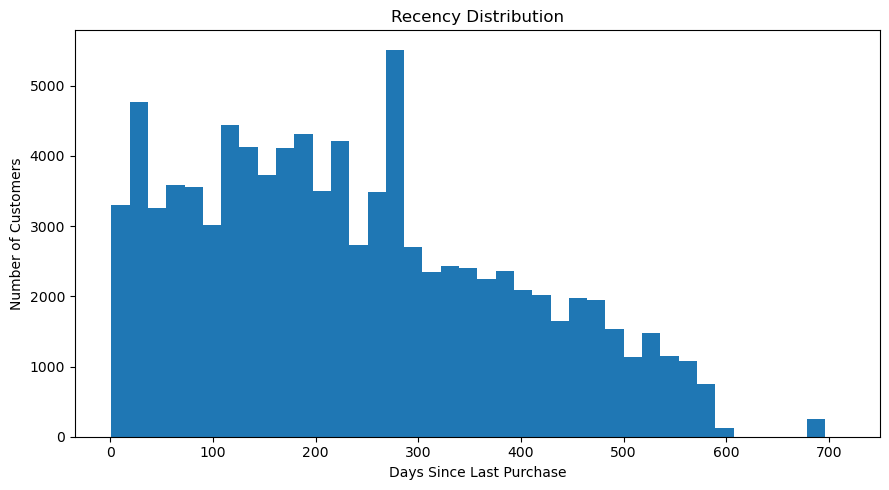

In [18]:
# Recency distribution
plt.figure(figsize=(9, 5))

plt.hist(
    rfm["recency"],
    bins=40
)

plt.title("Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

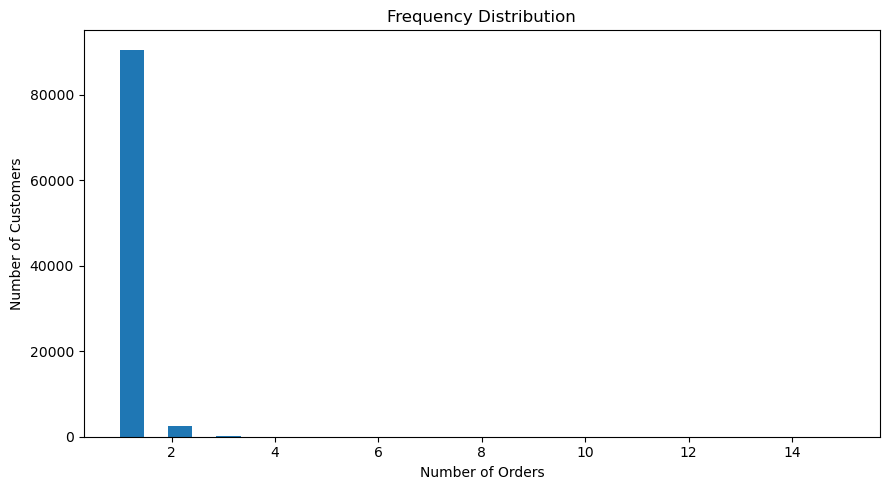

In [19]:
# Frequency distribution
plt.figure(figsize=(9, 5))

plt.hist(
    rfm["frequency"],
    bins=30
)

plt.title("Frequency Distribution")
plt.xlabel("Number of Orders")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

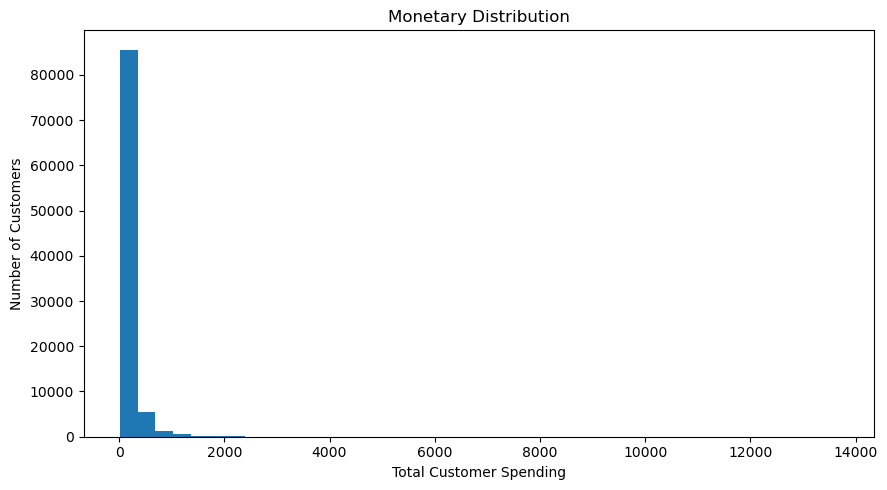

In [20]:
# Monetary distribution
plt.figure(figsize=(9, 5))

plt.hist(
    rfm["monetary"],
    bins=40
)

plt.title("Monetary Distribution")
plt.xlabel("Total Customer Spending")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

## 13. Log Transform RFM Variables

Frequency and Monetary values are typically right-skewed.

`log1p()` reduces the influence of extreme values while safely handling
zero values.

The transformed values are used only for clustering.
The original RFM values are retained for business interpretation.

In [21]:
# Select RFM variables for modeling
rfm_model = rfm[
    [
        "recency",
        "frequency",
        "monetary"
    ]
].copy()

# Log transformation
rfm_log = np.log1p(rfm_model)

display(rfm_log.head())

,recency,frequency,monetary
0,4.73,0.69,4.96
1,4.75,0.69,3.34
2,6.29,0.69,4.47
3,5.77,0.69,3.80
4,5.67,0.69,5.29


## 14. Standardize RFM Variables

RFM variables have different scales.

For example:

- Recency → days
- Frequency → number of orders
- Monetary → currency value

StandardScaler converts them to a comparable scale before K-Means clustering.

In [22]:
# Initialize scaler
scaler = StandardScaler()

# Standardize transformed RFM variables
rfm_scaled_array = scaler.fit_transform(rfm_log)

# Convert back to DataFrame
rfm_scaled = pd.DataFrame(
    rfm_scaled_array,
    columns=[
        "recency",
        "frequency",
        "monetary"
    ]
)

display(rfm_scaled.head())

,recency,frequency,monetary
0,-0.47,-0.17,0.29
1,-0.44,-0.17,-1.72
2,1.20,-0.17,-0.32
3,0.65,-0.17,-1.15
4,0.54,-0.17,0.69


## 15. Determine the Optimal Number of Clusters

K-Means requires the number of clusters (`K`) to be specified.

We evaluate K values from 2 to 8 using:

1. Elbow Method
2. Silhouette Score

The final K will be selected based on both the metrics and the business
interpretability of the resulting clusters.

In [23]:
# Store evaluation metrics
inertia = []
silhouette_scores = []

# Test K = 2 through 8
k_range = range(2, 9)

for k in k_range:

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(rfm_scaled)

    # Elbow metric
    inertia.append(kmeans.inertia_)

    # Silhouette metric
    silhouette_scores.append(
        silhouette_score(
            rfm_scaled,
            labels
        )
    )

## 16. Elbow Method

The Elbow Method examines how within-cluster variation decreases as the
number of clusters increases.

A noticeable bend in the curve indicates a reasonable candidate for K.

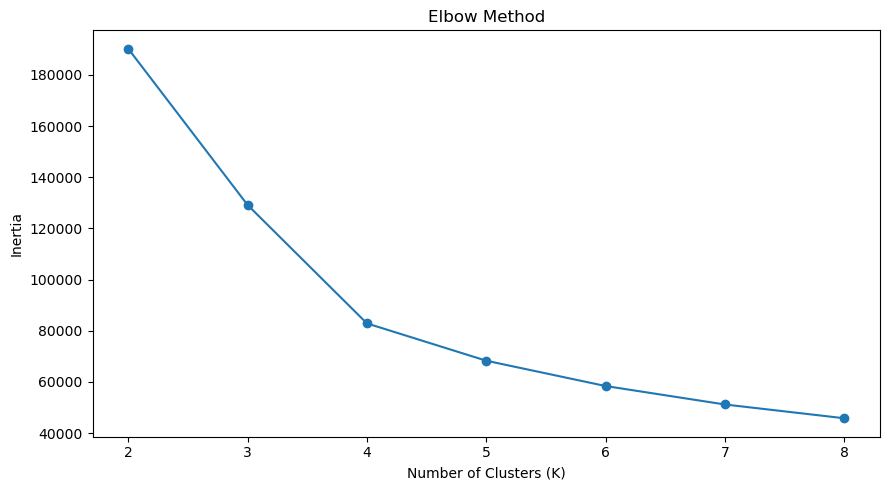

In [24]:
plt.figure(figsize=(9, 5))

plt.plot(
    list(k_range),
    inertia,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.xticks(list(k_range))

plt.tight_layout()
plt.show()

## 17. Silhouette Score

The Silhouette Score measures how well-separated the clusters are.

Higher values generally indicate better-defined clusters.

However, the highest score should not automatically be selected if the
result produces clusters that are difficult to interpret from a business
perspective.

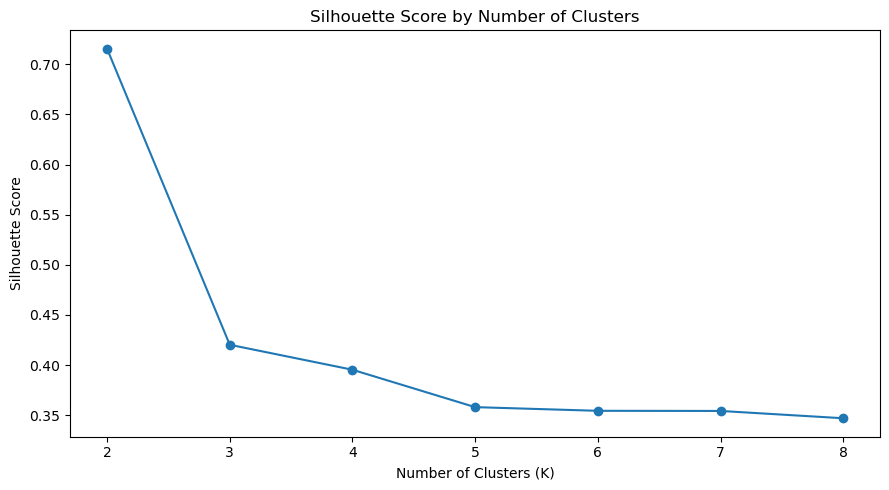

In [25]:
plt.figure(figsize=(9, 5))

plt.plot(
    list(k_range),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score by Number of Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.xticks(list(k_range))

plt.tight_layout()
plt.show()

## 18. Compare Clustering Metrics

In [26]:
for k, score in zip(
    k_range,
    silhouette_scores
):
    print(
        f"K = {k}: "
        f"Silhouette Score = {score:.4f}"
    )

K = 2: Silhouette Score = 0.7154
K = 3: Silhouette Score = 0.4203
K = 4: Silhouette Score = 0.3953
K = 5: Silhouette Score = 0.3581
K = 6: Silhouette Score = 0.3544
K = 7: Silhouette Score = 0.3543
K = 8: Silhouette Score = 0.3470


## 19. Select Final Number of Clusters

Review the Elbow Method and Silhouette Score above.

Select a K that provides:

- Reasonable clustering performance
- Clear customer differentiation
- Useful business interpretation

The selected K will be used for the final K-Means model.

In [27]:
# ---------------------------------------------------------
# IMPORTANT:
# Change this value after inspecting the Elbow and
# Silhouette plots.
# ---------------------------------------------------------

optimal_k = 4

print("Selected number of clusters:", optimal_k)

Selected number of clusters: 4


## 20. Train Final K-Means Model

The final K-Means model is trained using the selected number of clusters.

In [28]:
# Train final K-Means model
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

# Generate cluster labels
rfm["cluster"] = kmeans.fit_predict(
    rfm_scaled
)

# Check cluster distribution
display(
    rfm["cluster"]
    .value_counts()
    .sort_index()
)

cluster
0    32189
1    42285
2     2801
3    16083
Name: count, dtype: int64

## 21. Profile Customer Clusters

This is the most important step after clustering.

We examine each cluster using the original RFM values rather than the
scaled values.

This allows us to understand the actual behavior of customers in each group.

In [29]:
cluster_summary = (
    rfm
    .groupby("cluster")
    .agg(
        customers=(
            "customer_unique_id",
            "count"
        ),

        avg_recency=(
            "recency",
            "mean"
        ),

        avg_frequency=(
            "frequency",
            "mean"
        ),

        avg_monetary=(
            "monetary",
            "mean"
        ),

        total_monetary=(
            "monetary",
            "sum"
        )
    )
    .round(2)
)

# Add customer percentage
cluster_summary["customer_percentage"] = (
    cluster_summary["customers"]
    / cluster_summary["customers"].sum()
    * 100
).round(2)

display(
    cluster_summary
    .sort_values(
        "avg_monetary",
        ascending=False
    )
)

,customers,avg_recency,avg_frequency,avg_monetary,total_monetary,customer_percentage
cluster,,,,,,
2,2801,220.29,2.11,308.53,"864,187.46",3.00
0,32189,272.46,1.00,295.71,"9,518,486.78",34.48
3,16083,42.01,1.00,133.92,"2,153,806.18",17.23
1,42285,287.36,1.00,68.19,"2,883,293.33",45.29


## 22. Customer Segments

The following visualization compares customer Frequency and Monetary value
across the discovered clusters.

The cluster labels are still numerical at this stage.
Business-friendly names will only be assigned after inspecting the cluster
characteristics.

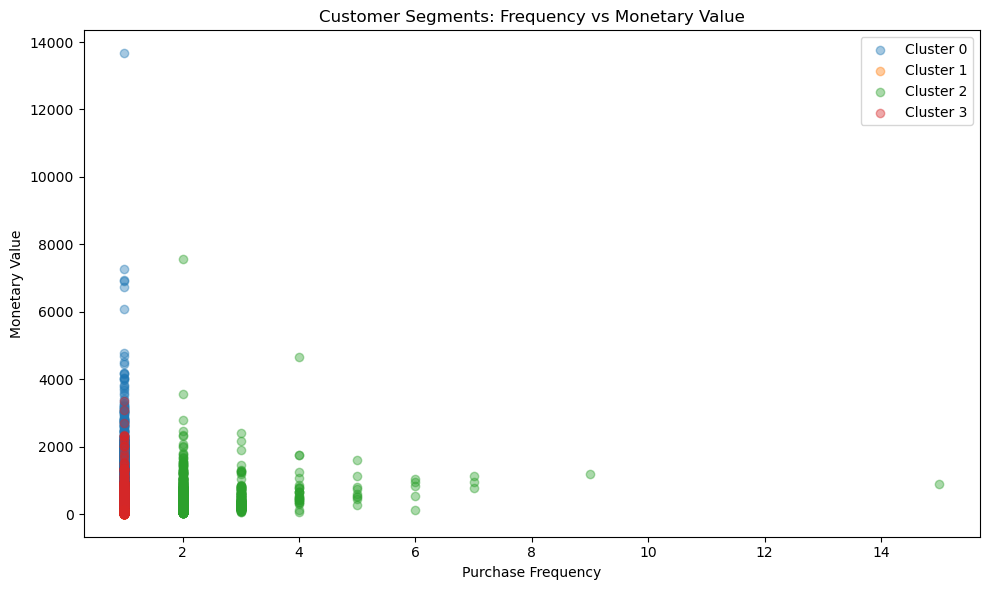

In [30]:
plt.figure(figsize=(10, 6))

for cluster in sorted(
    rfm["cluster"].unique()
):

    cluster_data = rfm[
        rfm["cluster"] == cluster
    ]

    plt.scatter(
        cluster_data["frequency"],
        cluster_data["monetary"],
        alpha=0.4,
        label=f"Cluster {cluster}"
    )

plt.title(
    "Customer Segments: Frequency vs Monetary Value"
)

plt.xlabel("Purchase Frequency")
plt.ylabel("Monetary Value")

plt.legend()

plt.tight_layout()
plt.show()

## 23. Interpret the Clusters

Cluster names should NOT be assigned before examining the cluster
characteristics.

Use the following general interpretation:

### High Frequency + High Monetary + Low Recency
Potentially high-value loyal/Champion customers.

### High Frequency + High Monetary + High Recency
Potentially valuable customers who may be at risk.

### Low Frequency + Low Monetary + Low Recency
Recent or new customers with limited purchase history.

### High Recency + Low Frequency + Low Monetary
Low-engagement or potentially lost customers.

The final business labels should be based on the actual cluster_summary
generated above.

## 24. Assign Business-Friendly Segment Names

The mapping below should be completed only after reviewing the actual
cluster characteristics.

In [31]:
# =========================================================
# 24. ASSIGN BUSINESS-FRIENDLY SEGMENT NAMES
# =========================================================

cluster_names = {
    0: "Occasional High-Spend Customers",
    1: "Low-Value Inactive Customers",
    2: "Loyal High-Value Customers",
    3: "Recent Customers"
}

# Map cluster numbers to business-friendly segment names
rfm["customer_segment"] = rfm["cluster"].map(cluster_names)

# Check the resulting segmentation
display(
    rfm[
        [
            "customer_unique_id",
            "recency",
            "frequency",
            "monetary",
            "cluster",
            "customer_segment"
        ]
    ].head(10)
)

,customer_unique_id,recency,frequency,monetary,cluster,customer_segment
0,0000366f3b9a7992bf8c76cfdf3221e2,112,1,141.90,0,Occasional High-Spend Customers
1,0000b849f77a49e4a4ce2b2a4ca5be3f,115,1,27.19,1,Low-Value Inactive Customers
2,0000f46a3911fa3c0805444483337064,537,1,86.22,1,Low-Value Inactive Customers
3,0000f6ccb0745a6a4b88665a16c9f078,321,1,43.62,1,Low-Value Inactive Customers
4,0004aac84e0df4da2b147fca70cf8255,288,1,196.89,0,Occasional High-Spend Customers
5,0004bd2a26a76fe21f786e4fbd80607f,146,1,166.98,0,Occasional High-Spend Customers
6,00050ab1314c0e55a6ca13cf7181fecf,132,1,35.38,1,Low-Value Inactive Customers
7,00053a61a98854899e70ed204dd4bafe,183,1,419.18,0,Occasional High-Spend Customers
8,0005e1862207bf6ccc02e4228effd9a0,543,1,150.12,0,Occasional High-Spend Customers
9,0005ef4cd20d2893f0d9fbd94d3c0d97,170,1,129.76,0,Occasional High-Spend Customers


## 25. Final Customer Segment Summary

Once the business-friendly cluster names have been assigned, summarize
customer count and monetary contribution by segment.

In [32]:
if "customer_segment" in rfm.columns:

    segment_summary = (
        rfm
        .groupby("customer_segment")
        .agg(
            customers=(
                "customer_unique_id",
                "count"
            ),

            avg_recency=(
                "recency",
                "mean"
            ),

            avg_frequency=(
                "frequency",
                "mean"
            ),

            avg_monetary=(
                "monetary",
                "mean"
            ),

            total_revenue=(
                "monetary",
                "sum"
            )
        )
        .round(2)
        .sort_values(
            "total_revenue",
            ascending=False
        )
    )

    segment_summary["customer_percentage"] = (
        segment_summary["customers"]
        / segment_summary["customers"].sum()
        * 100
    ).round(2)

    display(segment_summary)

else:

    print(
        "Assign cluster_names first, "
        "then run this cell."
    )

,customers,avg_recency,avg_frequency,avg_monetary,total_revenue,customer_percentage
customer_segment,,,,,,
Occasional High-Spend Customers,32189,272.46,1.00,295.71,"9,518,486.78",34.48
Low-Value Inactive Customers,42285,287.36,1.00,68.19,"2,883,293.33",45.29
Recent Customers,16083,42.01,1.00,133.92,"2,153,806.18",17.23
Loyal High-Value Customers,2801,220.29,2.11,308.53,"864,187.46",3.00


## 26. Customer Segment Distribution

The distribution of customers across the RFM segments is visualized
to understand the relative size of each customer group.

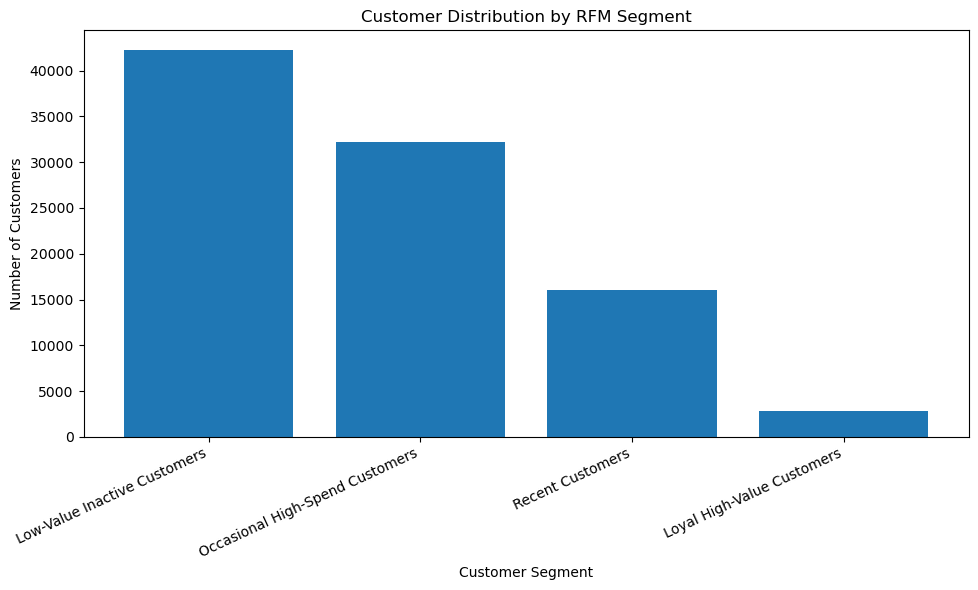

In [33]:
# =========================================================
# 26. CUSTOMER SEGMENT DISTRIBUTION
# =========================================================

import matplotlib.pyplot as plt

segment_counts = rfm["customer_segment"].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(
    segment_counts.index,
    segment_counts.values
)

plt.title("Customer Distribution by RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=25, ha="right")

plt.tight_layout()
plt.show()

## 26B. Baseline Comparison: Quantile-Based RFM Scoring vs. K-Means

Before adopting K-Means as the final segmentation approach, it is worth comparing it
against the traditional, industry-standard method: **quantile-based RFM scoring**.

In this approach, each of Recency, Frequency, and Monetary is independently split into
4 quartiles (1 = worst, 4 = best), summed into a single `RFM_score` (range 3-12), and
mapped to a segment using fixed score bands. This method is simple, fast, and requires
no machine learning — but it forces a roughly even ~25% split across each dimension by
construction, regardless of how the underlying data is actually distributed.

The goal here is not to prove K-Means is "better" in the abstract, but to check whether
its added complexity is actually justified by what it reveals about this specific
customer base.


In [34]:
# ---------------------------------------------------------
# Baseline: Quantile-based RFM scoring
# ---------------------------------------------------------

# Score each dimension 1-4 by quartile.
# Recency is inverted: more recent purchase = higher score.
r_labels = range(4, 0, -1)
f_labels = range(1, 5)
m_labels = range(1, 5)

rfm["R_score"] = pd.qcut(
    rfm["recency"].rank(method="first"), q=4, labels=r_labels
).astype(int)

rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"), q=4, labels=f_labels
).astype(int)

rfm["M_score"] = pd.qcut(
    rfm["monetary"].rank(method="first"), q=4, labels=m_labels
).astype(int)

rfm["RFM_score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]

# Map the combined score to a business segment using standard bands
def quantile_segment(row):
    if row["RFM_score"] >= 10:
        return "Champions"
    elif row["RFM_score"] >= 8:
        return "Loyal Customers"
    elif row["RFM_score"] >= 6:
        return "Potential Loyalists"
    elif row["RFM_score"] >= 4:
        return "At Risk"
    else:
        return "Lost / Inactive"

rfm["quantile_segment"] = rfm.apply(quantile_segment, axis=1)

print("Quantile-based segment sizes:")
print(rfm["quantile_segment"].value_counts())
print()
print("Quantile-based segment share (%):")
print((rfm["quantile_segment"].value_counts(normalize=True) * 100).round(2))


Quantile-based segment sizes:
quantile_segment
Potential Loyalists    31981
Loyal Customers        31103
Champions              15198
At Risk                13557
Lost / Inactive         1519
Name: count, dtype: int64

Quantile-based segment share (%):
quantile_segment
Potential Loyalists   34.26
Loyal Customers       33.32
Champions             16.28
At Risk               14.52
Lost / Inactive        1.63
Name: proportion, dtype: float64


## 26C. Side-by-Side Comparison: Segment Sizes


,K-Means Segment,K-Means %
0,Low-Value Inactive Customers,45.29
1,Occasional High-Spend Customers,34.48
2,Recent Customers,17.23
3,Loyal High-Value Customers,3.00


,Quantile Segment,Quantile %
0,Potential Loyalists,34.26
1,Loyal Customers,33.32
2,Champions,16.28
3,At Risk,14.52
4,Lost / Inactive,1.63


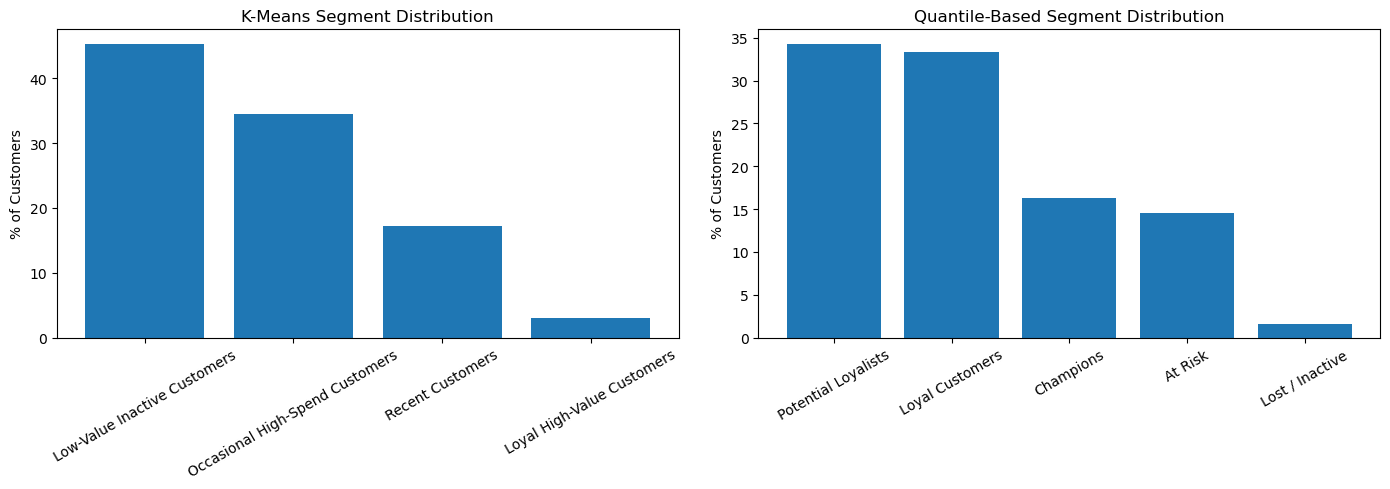

In [35]:
# ---------------------------------------------------------
# Compare segment sizes: Quantile baseline vs. K-Means
# ---------------------------------------------------------

kmeans_sizes = (rfm["customer_segment"].value_counts(normalize=True) * 100).round(2)
quantile_sizes = (rfm["quantile_segment"].value_counts(normalize=True) * 100).round(2)

comparison = pd.DataFrame({
    "K-Means Segment": kmeans_sizes.index,
    "K-Means %": kmeans_sizes.values
})
display(comparison)

comparison_baseline = pd.DataFrame({
    "Quantile Segment": quantile_sizes.index,
    "Quantile %": quantile_sizes.values
})
display(comparison_baseline)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(kmeans_sizes.index, kmeans_sizes.values)
axes[0].set_title("K-Means Segment Distribution")
axes[0].set_ylabel("% of Customers")
axes[0].tick_params(axis="x", rotation=30)

axes[1].bar(quantile_sizes.index, quantile_sizes.values)
axes[1].set_title("Quantile-Based Segment Distribution")
axes[1].set_ylabel("% of Customers")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


## 26D. Where the Two Methods Disagree

A crosstab shows how customers in each K-Means cluster are distributed across the
quantile-based segments. If the two methods agreed closely, each K-Means segment
would map cleanly onto one quantile segment (high purity). Low purity means the
methods are drawing meaningfully different conclusions about the same customers.


In [36]:
# ---------------------------------------------------------
# Crosstab: K-Means segment vs. Quantile segment
# ---------------------------------------------------------

crosstab = pd.crosstab(rfm["customer_segment"], rfm["quantile_segment"])
display(crosstab)

# Purity: for each K-Means segment, what % falls into its single most common
# quantile segment?
purity = crosstab.div(crosstab.sum(axis=1), axis=0) * 100
display(purity.round(1))


quantile_segment,At Risk,Champions,Lost / Inactive,Loyal Customers,Potential Loyalists
customer_segment,,,,,
Low-Value Inactive Customers,12556,563,1519,8466,19181
Loyal High-Value Customers,0,1869,0,841,91
Occasional High-Spend Customers,1001,7250,0,14359,9579
Recent Customers,0,5516,0,7437,3130


quantile_segment,At Risk,Champions,Lost / Inactive,Loyal Customers,Potential Loyalists
customer_segment,,,,,
Low-Value Inactive Customers,29.70,1.30,3.60,20.00,45.40
Loyal High-Value Customers,0.00,66.70,0.00,30.00,3.20
Occasional High-Spend Customers,3.10,22.50,0.00,44.60,29.80
Recent Customers,0.00,34.30,0.00,46.20,19.50


## 26E. Why K-Means Was Chosen Over Quantile-Based Scoring

**Finding:** The quantile method classifies only **~1.6%** of customers as "Lost /
Inactive," and puts the largest share (**~34%**) into a vague "Potential Loyalists"
bucket. K-Means, by contrast, identifies **45.3%** of customers as genuinely
**Low-Value / Inactive** — a segment nearly 28x larger than the quantile method's
equivalent category.

This is not a modeling artifact — it is a structural limitation of quantile scoring.
Because each RFM dimension is forced into even quartiles by construction, the method
cannot represent a customer base where a large share of activity is genuinely
concentrated at the low end (as is the case here: the majority of Olist customers are
one-time, low-spend buyers). Quantile scoring effectively guarantees a "smooth"-looking
segment distribution regardless of what the actual data looks like, which understates
how large the low-value segment truly is.

The crosstab above shows the practical consequence: a large share of customers the
quantile method calls "Potential Loyalists" or "At Risk" are, in the K-Means view,
firmly Low-Value / Inactive. Acting on the quantile method's labels alone would direct
retention/marketing spend toward customers who are, in reality, unlikely to convert —
while K-Means correctly isolates the small, genuinely valuable **Loyal High-Value**
segment (3% of customers) that the quantile method spreads thinly across "Champions"
and "Loyal Customers" instead.

**Conclusion:** K-Means' added complexity is justified here — it captures the true
shape of the customer base (a large, real low-value tail) that a fixed-quartile
baseline structurally cannot see, and this materially changes which customers a
retention campaign should target.


## 27. Export RFM Results

The final customer-level RFM segmentation and segment-level summary
are exported for further analysis and Power BI visualization.

In [37]:
# Final customer-level RFM dataset
rfm_final = rfm[
    [
        "customer_unique_id",
        "recency",
        "frequency",
        "monetary",
        "cluster",
        "customer_segment"
    ]
].copy()

# Export customer-level segmentation
rfm_final.to_csv(
    "../data/processed/rfm_customer_segments.csv",
    index=False
)

# Export segment-level summary
segment_summary.to_csv(
    "../data/processed/rfm_segment_summary.csv"
)

print("RFM analysis completed successfully.")
print("Customer-level RFM file exported.")
print("Segment-level summary exported.")

RFM analysis completed successfully.
Customer-level RFM file exported.
Segment-level summary exported.
